Monte carlo simulatie voor de depressiegraaf

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


In [2]:
#initializing the graph, hard coded from the board
#we use the connection matrix defined during the yap session
"""
1: Concentratie
2: Traag/Zenuwachtig
3: Suicidaal
4: Laag zelfbeeld
5: Weinig interesse
6: Neerslachtig
7: Slechte slaap
8: Moe
9: Eetstoornis

We doen verbindings_matrix[i,j] is van i naar j
"""
verbindings_matrix = [[0,6,0,0,0,0,0,0,0], 
                      [6,0,0,1,0,0,4,0,0], 
                      [0,0,0,8,3,0,9,0,0], 
                      [0,0,3,7,5,2,1,0,2], 
                      [0,2,1,0,3,0,0,0,1], 
                      [0,2,1,2,7,3,0,0,2], 
                      [0,0,0,1,0,0,1,10,0], 
                      [7,2,0,3,4,4,-3,0,0], 
                      [1,4,0,4,0,0,2,2,1]]

extern_veld = [0,0,0,0,0,0,0,0,0] #naar wens aan te passen, kan normaal ook over gesweept worden

model_params = [verbindings_matrix, extern_veld]

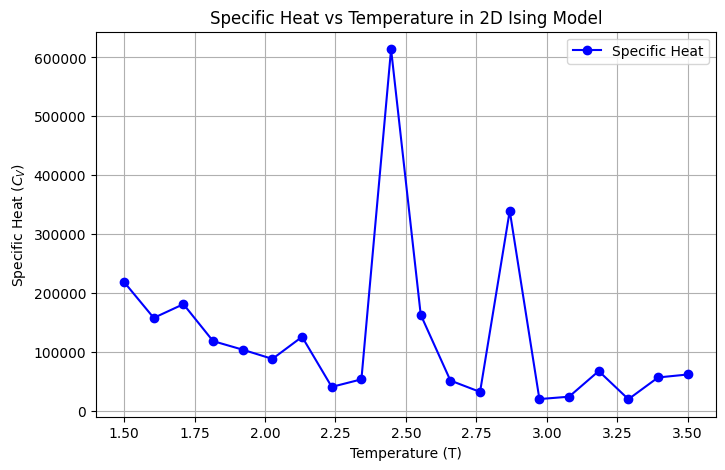

[-0.2  0.1 -0.2 -0.2  0.1  0.1 -0.3  0.  -0.3]


In [29]:
# Monte carlo simulatie met credits naar prof. Enrico Carlon, aangepast om op de depressiegraaf te runnen
def initialize_lattice(L):
    """Initialize an LxL lattice with random spins (+1 or -1)."""
    return np.random.choice([-1, 1], size=(L))
#@njit
def compute_energy(lattice, parameters):
    """Compute the total energy of the lattice."""
    intern = parameters[0]
    extern = parameters[1]
    energy = 0
    L = len(lattice)
    diag_counter = np.ones(L) #to prevent double counting the diagonal
    for i in range(L):
        external = lattice[i]*extern[i]
        internal = 0
        for j in range(L):
            if i != j:
                internal += lattice[i]*lattice[j]*intern[i][j]
            elif diag_counter[i] == 1:
                internal += lattice[i]*lattice[j]*intern[i][j]
                diag_counter[i] += 1
        energy += external + internal            
    return energy
#@njit
def metropolis_step(lattice, beta, parameters):
    """Perform one Metropolis update step."""
    L = len(lattice)
    dE = 0
    new_latice = lattice.copy()
    initial_energy = compute_energy(lattice, parameters)
    for _ in range(L):
        i = np.random.randint(0, L)
        S = new_latice[i]
        new_latice[i] = -S
        new_E = compute_energy(new_latice, parameters)
        delta_E = new_E - initial_energy
        prob = np.exp(beta*delta_E)
        if delta_E < 0 or np.random.rand() < prob:
            lattice[i] *= -1
            dE += delta_E
    return dE
def simulate_ising(L, T, sweeps, equilib_sweeps, parameters):
    """Simulate the Ising model and compute average energy & energy squared"""
    beta = 1.0 / T
    lattice = initialize_lattice(L)
    #lattices = []
### Precompute an array with the possible values of the energy change
### and Metropolis probabilities
    E = compute_energy(lattice, parameters)
    for _ in range(equilib_sweeps):
        E += metropolis_step(lattice, beta, parameters)
    E_total=E;E2_total=E**2
    for _ in range(sweeps):
        E += metropolis_step(lattice, beta, parameters)
        E_total += E
        E2_total += E**2
    E_avg=E_total/sweeps;E2_avg=E2_total/sweeps
    return E_avg, E2_avg, lattice
def compute_model(parameters, L, T_values, sweeps, equilib_sweeps=100):
    """Compute specific heat over a range of temperatures."""
    C_V_values = []
    lattices = []
    for T in T_values:
    # print(f"T: {T:.2f}")
        E_avg, E2_avg, latc = simulate_ising(L, T, sweeps, equilib_sweeps, parameters)
        C_V = (E2_avg - E_avg**2) / (T**2 * L**2)
        C_V_values.append(C_V)
        lattices.append(latc)
    return C_V_values, lattices
### Simulation Parameters
L = 9 # Lattice size
T_values = np.linspace(1.5, 3.5, 20) # Temperature range
sweeps = 10000 # Number of Monte Carlo sweeps
equilib_sweeps = 100 # Number of equilibration sweeps
# Compute Specific Heat
C_V_values, lattices = compute_model(model_params, L, T_values, sweeps, equilib_sweeps)
# print('C_V_values:', C_V_values)
# Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(T_values, C_V_values, 'bo-', label='Specific Heat')
plt.xlabel('Temperature (T)')
plt.ylabel('Specific Heat ($C_V$)')
plt.title('Specific Heat vs Temperature in 2D Ising Model')
plt.legend()
plt.grid()
plt.show()
avg_lattice_vals = np.sum(lattices, axis=0)/len(lattices)
print(avg_lattice_vals)

In [27]:
np.sum(lattices, 0)
len(lattices)
lattices

[array([-1,  1, -1,  1, -1, -1,  1,  1,  1]),
 array([ 1,  1, -1,  1, -1, -1,  1,  1, -1]),
 array([ 1, -1,  1,  1,  1, -1,  1, -1,  1]),
 array([-1, -1,  1,  1,  1, -1,  1,  1,  1]),
 array([ 1, -1,  1, -1, -1,  1,  1, -1,  1]),
 array([ 1,  1,  1,  1, -1,  1,  1, -1, -1]),
 array([ 1,  1, -1,  1, -1,  1, -1,  1,  1]),
 array([ 1,  1,  1, -1, -1, -1, -1,  1, -1]),
 array([ 1, -1,  1,  1,  1,  1, -1,  1,  1]),
 array([ 1,  1, -1,  1,  1, -1,  1, -1, -1]),
 array([-1, -1,  1, -1,  1, -1,  1,  1,  1]),
 array([-1,  1, -1, -1, -1, -1,  1,  1,  1]),
 array([ 1, -1, -1,  1, -1,  1, -1, -1,  1]),
 array([-1,  1, -1, -1,  1, -1, -1, -1, -1]),
 array([ 1,  1,  1, -1,  1,  1,  1, -1,  1]),
 array([ 1, -1, -1, -1,  1,  1, -1, -1,  1]),
 array([ 1,  1, -1, -1,  1,  1, -1, -1,  1]),
 array([-1, -1, -1, -1,  1,  1,  1, -1,  1]),
 array([ 1, -1, -1,  1, -1,  1, -1, -1, -1]),
 array([-1, -1,  1,  1, -1,  1,  1,  1,  1])]